# Assignment 2 — 序列语言模型（GPU 版，Cosmopedia 直连）
**Author:** _Zhang Jingxuan_    **Date:** 2025-09-10

- 强制使用 **HuggingFace Cosmopedia**（或其 100k 子集）作为原始语料，不再使用任何示例文本；
- 自动优先选择 **GPU (cuda)**，检测不到时回落到 **cpu**；
- 内置 DataLoader 与 CUDA 优化（pin_memory / num_workers / TF32）。


## 1. 环境与设备（优先 GPU）

In [61]:
from tqdm.auto import tqdm
import sys, os, math, time, random, re
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cuda":
    try:
        print("GPU:", torch.cuda.get_device_name(0))
        # CUDA performance tweaks
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.backends.cudnn.benchmark = True
    except Exception as e:
        print("GPU info error:", e)

Python: 3.9.19 (main, May  6 2024, 20:12:36) [MSC v.1916 64 bit (AMD64)]
PyTorch: 2.5.1+cu121
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. 从 HuggingFace Cosmopedia 加载语料（强制使用）
> 默认启用 **streaming**，并通过条数/字符上限控制规模。可先用 `cosmopedia-100k` 做流程验证。


In [62]:
#  If needed: uncomment next line to install packages
#  %pip -q install datasets huggingface_hub

from datasets import load_dataset
from pathlib import Path

#  Note: comment replaced from Chinese
HF_DATASET_NAME = "HuggingFaceTB/cosmopedia"      #   "HuggingFaceTB/cosmopedia-100k"
HF_CONFIG = "stories"                              #  auto_math_text / khanacademy / openstax / stanford / stories / web_samples_v1 / web_samples_v2 / wikihow
HF_SPLIT = "train"
HF_STREAMING = True                                #   True
HF_SAMPLE_LIMIT = 2000000                           #  （；）
HF_MAX_CHARS = 2000000                     #  （）
HF_TEXT_FIELD = "text"
HF_FILTER_FORMAT = None                            #  :  -> "textbook"

def load_corpus_from_hf(
    dataset_name=HF_DATASET_NAME, config=HF_CONFIG, split=HF_SPLIT,
    streaming=HF_STREAMING, sample_limit=HF_SAMPLE_LIMIT, max_chars=HF_MAX_CHARS,
    text_field=HF_TEXT_FIELD, filter_format=HF_FILTER_FORMAT
):
    if streaming:
        ds = load_dataset(dataset_name, config, split=split, streaming=True)
        total_chars, total_rows = 0, 0
        texts = []
        for ex in ds:
            if filter_format is not None and ex.get("format", None) != filter_format:
                continue
            t = ex.get(text_field, None)
            if not t:
                continue
            texts.append(t.strip())
            total_rows += 1
            total_chars += len(t)
            if sample_limit is not None and total_rows >= sample_limit:
                break
            if max_chars is not None and total_chars >= max_chars:
                break
        raw_text = "\n\n".join(texts)
        return raw_text, dict(rows=total_rows, chars=len(raw_text), streaming=True)
    else:
        ds = load_dataset(dataset_name, config, split=split)
        if filter_format is not None and "format" in ds.column_names:
            ds = ds.filter(lambda ex: ex.get("format", None) == filter_format)
        if sample_limit is not None:
            ds = ds.select(range(min(sample_limit, len(ds))))
        texts = [t.strip() for t in ds[text_field] if isinstance(t, str)]
        raw_text = "\n\n".join(texts)
        if max_chars is not None and len(raw_text) > max_chars:
            raw_text = raw_text[:max_chars]
        return raw_text, dict(rows=len(texts), chars=len(raw_text), streaming=False)

print("Loading Cosmopedia:", HF_DATASET_NAME, "| config:", HF_CONFIG, "| split:", HF_SPLIT)
raw_text, info = load_corpus_from_hf()
print(f"Fetched rows={info['rows']}  chars={info['chars']}  streaming={info['streaming']}")

#  Persist corpus for reproducibility — save under data/
save_dir = Path.cwd() / "data"
save_dir.mkdir(parents=True, exist_ok=True)  #   data 
out_txt = save_dir / "cosmopedia_corpus.txt"
out_txt.write_text(raw_text, encoding="utf-8")
print("Saved concatenated corpus to:", out_txt.resolve())

Loading Cosmopedia: HuggingFaceTB/cosmopedia | config: stories | split: train


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

Fetched rows=741  chars=2000903  streaming=True
Saved concatenated corpus to: D:\Coding_Nus\DSA4213\DSA4213_Natural-Language-Processing-for-Data-Science\data\cosmopedia_corpus.txt


In [3]:
# Quick smoke test: use the first 2000 characters from the saved corpus file
from pathlib import Path

corpus_path = Path("data/cosmopedia_corpus.txt")
if not corpus_path.exists():
    raise FileNotFoundError("data/cosmopedia_corpus.txt not found. Please run the dataset loading cell first.")

full_text = corpus_path.read_text(encoding="utf-8")
raw_text = full_text[:20000]  # override the global raw_text used by training
print(f"[Smoke Test] Using the first 20000 characters from: {corpus_path}")
print("Length of raw_text:", len(raw_text))
print("Preview (first 400 chars):\n", raw_text[:400].replace("\n", "\\n"))

[Smoke Test] Using the first 20000 characters from: data\cosmopedia_corpus.txt
Length of raw_text: 20000
Preview (first 400 chars):
 Once upon a time, in a village called Kiwiland, there lived two best friends named Kiwi and Koala. They loved exploring the world around them and learning new things every day! One day, they stumbled upon a magical forest full of vibrant colors and fascinating creatures. As they ventured deeper into the forest, they met Torty, a wise old turtle who was known to have answers to all questions.\n\nKiwi


## 3. 训练配置与消融表（GPU 友好默认）

In [40]:
import pandas as pd

DEFAULTS = dict(
    tokenizer="char",   # "char" | "word"
    seq_len=256,
    emb_dim=256,
    hidden=256,
    num_layers=1,
    nhead=4,
    tfm_layers=2,
    dropout=0.1,
    batch_size=32,
    epochs=30,
    lr=3e-4,
    clip=1.0,
    seed=42,
    device=("cuda" if torch.cuda.is_available() else "cpu"),
    log_every=50,
    max_tokens=None,
)

# You may tweak these; start with a small run to validate the pipeline
ORIGINAL_ABLATIONS = [
    # 1) LSTM, char, seq_len=256, dropout=0.0 vs 0.2（dropout 对比）
    dict(model="lstm",        tokenizer="char", seq_len=256, dropout=0.0, epochs=30, batch_size=32),
    dict(model="lstm",        tokenizer="char", seq_len=256, dropout=0.2, epochs=30, batch_size=32),

    # 2) Transformer, char, context length 对比：128 vs 256
    dict(model="transformer", tokenizer="char", seq_len=128, dropout=0.1, epochs=30, batch_size=32),
    dict(model="transformer", tokenizer="char", seq_len=256, dropout=0.1, epochs=30, batch_size=16),

    # 3) tokenization 对比：word vs char（任选一个模型）
    dict(model="transformer", tokenizer="word", seq_len=128, dropout=0.1, epochs=30, batch_size=32),
    dict(model="lstm",        tokenizer="word", seq_len=256, dropout=0.2, epochs=30, batch_size=32),
]
FAST_MODE = False

ABLATIONS = [dict(model="transformer", tokenizer="char", seq_len=128, dropout=0.1, epochs=30, batch_size=32)] if FAST_MODE else ORIGINAL_ABLATIONS
OUT_DIR = Path("results"); OUT_DIR.mkdir(exist_ok=True, parents=True)
for ablation in ABLATIONS:
    print(ablation)

# DataLoader tuning (on Windows, if multiprocessing causes issues, set num_workers=0)
NUM_WORKERS = 0            # <- KEY: single-process loader
PIN_MEMORY  = bool(torch.cuda.is_available())  # OK to keep True
print("NUM_WORKERS =", NUM_WORKERS, "| PIN_MEMORY =", PIN_MEMORY)

{'model': 'lstm', 'tokenizer': 'char', 'seq_len': 256, 'dropout': 0.0, 'epochs': 30, 'batch_size': 32}
{'model': 'lstm', 'tokenizer': 'char', 'seq_len': 256, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32}
{'model': 'transformer', 'tokenizer': 'char', 'seq_len': 128, 'dropout': 0.1, 'epochs': 30, 'batch_size': 32}
{'model': 'transformer', 'tokenizer': 'char', 'seq_len': 256, 'dropout': 0.1, 'epochs': 30, 'batch_size': 16}
{'model': 'transformer', 'tokenizer': 'word', 'seq_len': 128, 'dropout': 0.1, 'epochs': 30, 'batch_size': 32}
{'model': 'lstm', 'tokenizer': 'word', 'seq_len': 256, 'dropout': 0.2, 'epochs': 30, 'batch_size': 32}
NUM_WORKERS = 0 | PIN_MEMORY = True


## 4. 工具函数

In [41]:
def set_seed(seed: int = 42):
    import random, numpy as np, torch
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def save_plot(train_losses, val_losses, out_png):
    plt.figure()
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.title("Training / Validation Loss")
    plt.tight_layout(); plt.savefig(out_png); plt.show()

## 5. 分词器

In [42]:
class CharTokenizer:
    def __init__(self, text: str):
        chars = sorted(list(set(text)))
        self.stoi = {c:i for i,c in enumerate(chars)}
        self.itos = {i:c for c,i in self.stoi.items()}
        self.vocab_size = len(self.stoi)
    def encode(self, text: str): return [self.stoi[c] for c in text if c in self.stoi]
    def decode(self, ids): return "".join(self.itos[i] for i in ids)

import re as _re
class WordTokenizer:
    WORD_RE = _re.compile(r"\w+|[^\w\s]", _re.UNICODE)
    def __init__(self, text: str, min_freq: int = 1, max_vocab: int = 50000):
        toks = self.WORD_RE.findall(text); freq = {}
        for t in toks: freq[t] = freq.get(t, 0) + 1
        items = sorted(freq.items(), key=lambda x:(-x[1], x[0]))[:max_vocab]
        self.stoi = {tk:i for i,(tk,cnt) in enumerate(items) if cnt >= min_freq}
        self.itos = {i:tk for tk,i in self.stoi.items()}
        self.unk = len(self.stoi); self.stoi["<UNK>"]=self.unk; self.itos[self.unk]="<UNK>"
        self.vocab_size = len(self.stoi)
    def encode(self, text: str):
        return [self.stoi.get(t, self.unk) for t in self.WORD_RE.findall(text)]
    def decode(self, ids): return " ".join(self.itos[i] for i in ids)

## 6. 数据集与切块（80/10/10）

In [43]:
class LMSequenceDataset(Dataset):
    def __init__(self, ids: List[int], seq_len: int):
        self.ids = ids; self.seq_len = seq_len
        self.num_seq = (len(ids) - 1) // seq_len
    def __len__(self): return self.num_seq
    def __getitem__(self, idx):
        s = idx * self.seq_len
        x = torch.tensor(self.ids[s:s+self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[s+1:s+self.seq_len+1], dtype=torch.long)
        return x, y

def split_data(tokens: List[int], ratios=(0.8,0.1,0.1)):
    n=len(tokens); i=int(n*ratios[0]); j=int(n*(ratios[0]+ratios[1])); return tokens[:i], tokens[i:j], tokens[j:]

## 7. 模型：LSTM LM 与 Causal Transformer LM

In [44]:
class LSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, vocab_size)
    def forward(self, x, hidden=None):
        x=self.embed(x); out, hidden=self.lstm(x, hidden); out=self.drop(out); return self.fc(out), hidden

class CausalTransformer(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, nhead=4, num_layers=2, dropout=0.1, max_len=1024):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim)
        self.pos_emb = nn.Embedding(max_len, emb_dim)
        enc_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=nhead,
                                               dim_feedforward=4*emb_dim, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.ln_f = nn.LayerNorm(emb_dim)
        self.fc = nn.Linear(emb_dim, vocab_size)
        self.max_len = max_len
    def forward(self, x):
        B,T=x.size(); pos=torch.arange(0,T,device=x.device).unsqueeze(0).expand(B,T)
        h=self.token_emb(x)+self.pos_emb(pos)
        mask=torch.triu(torch.ones(T,T,device=x.device)*float("-inf"), diagonal=1)
        h=self.encoder(h, mask=mask); h=self.ln_f(h); return self.fc(h)

## 8. 训练 / 评估 / 生成

In [53]:
import math, random, time
import torch
import torch.nn as nn

def build_tokenizer(text: str, kind: str):
    if kind == "char":
        return CharTokenizer(text)
    if kind == "word":
        return WordTokenizer(text)
    raise ValueError("tokenizer must be 'char' or 'word'")

def eval_loader(loader, model, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)[0] if isinstance(model, LSTMLM) else model(x)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1)
            )
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()
    avg = total_loss / max(1, total_tokens)
    ppl = math.exp(avg) if avg < 20 else float("inf")
    return avg, ppl

def sample_generate(
    model, tok, seq_len: int, device: str,
    max_new_tokens: int = 200,
    temperature: float = 1.0,          # 仍支持温度
    strategy: str = "temperature",     # 'greedy' | 'temperature' | 'topk' | 'topp'
    top_k: int = 50,
    top_p: float = 0.9,
    start_text: str = ""
):
    model.eval()
    ids = tok.encode(start_text) if start_text else [random.randrange(tok.vocab_size)]
    ids = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            x = ids[:, -seq_len:]
            logits = model(x)[0] if isinstance(model, LSTMLM) else model(x)
            logits = logits[:, -1, :]

            if strategy == "greedy":
                next_id = torch.argmax(logits, dim=-1, keepdim=True)

            elif strategy == "topk":
                k = min(top_k, logits.size(-1))
                vals, idxs = torch.topk(logits, k, dim=-1)
                if temperature and temperature > 0:
                    vals = vals / temperature
                probs = torch.softmax(vals, dim=-1)
                choice = torch.multinomial(probs, 1)
                next_id = idxs.gather(-1, choice)

            elif strategy == "topp":
                if temperature and temperature > 0:
                    logits = logits / temperature
                probs = torch.softmax(logits, dim=-1)
                sorted_probs, sorted_idx = torch.sort(probs, descending=True)
                cumsum = torch.cumsum(sorted_probs, dim=-1)
                mask = cumsum > top_p
                mask[..., 0] = False           # 至少保留1个
                sorted_probs = sorted_probs.masked_fill(mask, 0.0)
                sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
                choice = torch.multinomial(sorted_probs, 1)
                next_id = sorted_idx.gather(-1, choice)

            else:  # 'temperature'
                if temperature and temperature > 0:
                    logits = logits / temperature
                probs = torch.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, 1)

            ids = torch.cat([ids, next_id], dim=1)

    return tok.decode(ids[0].tolist())

def run_single_experiment(raw_text: str, cfg: Dict[str, Any], label: str):
    conf = {**DEFAULTS, **cfg}
    set_seed(conf["seed"])

    # --- Tokenize ---
    tok = build_tokenizer(raw_text, conf["tokenizer"])
    ids = tok.encode(raw_text)
    # Optional truncation for faster runs
    if conf.get("max_tokens"):
        ids = ids[:conf["max_tokens"]]

    # --- Split tokens -> sequences ---
    tr_ids, va_ids, te_ids = split_data(ids, (0.8, 0.1, 0.1))
    train_set = LMSequenceDataset(tr_ids, conf["seq_len"])
    val_set   = LMSequenceDataset(va_ids, conf["seq_len"])
    test_set  = LMSequenceDataset(te_ids, conf["seq_len"])

    # ---- Small-data guard: adapt batch_size / drop_last to avoid 0 steps ----
    def _effective_bs_and_drop(ds_len: int, want_bs: int):
        if ds_len <= 0:
            return 1, False  # avoid crash; we'll just skip effectively
        if ds_len < want_bs:
            return ds_len, False  # use smaller bs and keep the last partial
        return want_bs, True     # normal case

    eff_bs, drop_train = _effective_bs_and_drop(len(train_set), conf["batch_size"])

    train_loader = DataLoader(
        train_set, batch_size=eff_bs, shuffle=True, drop_last=drop_train,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=False
)
    val_loader = DataLoader(
        val_set, batch_size=max(1, min(conf["batch_size"], len(val_set))),
        shuffle=False, drop_last=False, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY, persistent_workers=False
)
    test_loader = DataLoader(
        test_set, batch_size=max(1, min(conf["batch_size"], len(test_set))),
        shuffle=False, drop_last=False, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY, persistent_workers=False
)

    # --- Model ---
    model = (
        LSTMLM(
            tok.vocab_size, emb_dim=conf["emb_dim"], hidden=conf["hidden"],
            num_layers=conf["num_layers"], dropout=conf["dropout"]
        ).to(conf["device"])
        if conf["model"] == "lstm" else
        CausalTransformer(
            tok.vocab_size, emb_dim=conf["emb_dim"], nhead=conf["nhead"],
            num_layers=conf["tfm_layers"], dropout=conf["dropout"],
            max_len=max(1024, conf["seq_len"])
        ).to(conf["device"])
    )

    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.AdamW(model.parameters(), lr=conf["lr"])

    # --- AMP (new API) with fallback for older PyTorch ---
    use_amp = (conf["device"] == "cuda")
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=use_amp)  # PyTorch ≥2.3
    except Exception:
        scaler = make_grad_scaler(use_amp)    # older versions

    print("Steps/epoch:", len(train_loader))
    print("Total steps this run:", len(train_loader) * conf["epochs"])

    # If still zero, print hint and short-circuit to a no-op run
    if len(train_loader) == 0:
        print("[Warning] No training batches. Likely too few sequences "
              f"(seq_len={conf['seq_len']}) or batch_size too large (bs={conf['batch_size']}). "
              "Try smaller seq_len or batch_size, or increase corpus/max_tokens.")
        # Compute validation/test anyway (safe inside eval_loader)
        va_avg, va_ppl = eval_loader(val_loader, model, criterion, conf["device"])
        te_loss, te_ppl = eval_loader(test_loader, model, criterion, conf["device"])
        train_losses, val_losses = [0.0], [va_avg]
        fig_path = OUT_DIR / f"loss_{label}.png"
        save_plot(train_losses, val_losses, str(fig_path))
        gens = {k: "" for k in ["greedy","temp0.7","temp1.0","temp1.3","topk50","topp0.9"]}
        rec = dict(
            label=label, model=conf["model"], tokenizer=conf["tokenizer"],
            seq_len=conf["seq_len"], dropout=conf["dropout"], epochs=conf["epochs"],
            batch_size=conf["batch_size"], lr=conf["lr"], emb_dim=conf["emb_dim"],
            val_loss=va_avg,
            val_ppl=va_ppl,
            test_loss=te_loss, test_ppl=te_ppl,
            train_time_sec=0.0, curve=str(fig_path)
        )
        for T in gens: rec[f"gen_T{T}"] = ""
        return rec, train_losses, val_losses, gens

    # --- Train ---
    train_losses, val_losses = [], []
    t0_all = time.time()
    for ep in range(1, conf["epochs"] + 1):
        model.train()
        run_loss = 0.0
        run_tok = 0
        t0 = time.time()

        bar = tqdm(train_loader, leave=False, desc=f"Epoch {ep}/{conf['epochs']}")
        for step, (x, y) in enumerate(bar, 1):
            x = x.to(conf["device"], non_blocking=True)
            y = y.to(conf["device"], non_blocking=True)

            opt.zero_grad(set_to_none=True)
            with amp_autocast_ctx(use_amp):
                logits = model(x)[0] if isinstance(model, LSTMLM) else model(x)
                loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            scaler.scale(loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), conf["clip"])
            scaler.step(opt)
            scaler.update()

            run_loss += loss.item() * y.numel()
            run_tok  += y.numel()
            if step % conf.get("log_every", 50) == 0:
                bar.set_postfix(avg_loss=run_loss / max(1, run_tok))

        tr_avg = run_loss / max(1, run_tok)  # avoid ZeroDivisionError
        va_avg, va_ppl = eval_loader(val_loader, model, criterion, conf["device"])
        train_losses.append(tr_avg)
        val_losses.append(va_avg)
        print(
            f"[{label}] Epoch {ep}/{conf['epochs']} "
            f"train={tr_avg:.4f} val={va_avg:.4f} valPPL={va_ppl:.2f} "
            f"time={time.time()-t0:.1f}s"
        )

    total_time = time.time() - t0_all
    te_loss, te_ppl = eval_loader(test_loader, model, criterion, conf["device"])

    # --- Save curves ---
    fig_path = OUT_DIR / f"loss_{label}.png"
    save_plot(train_losses, val_losses, str(fig_path))

    # --- Sampling ---
    gens = {
        "greedy":  sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="greedy"),
        "temp0.7": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="temperature", temperature=0.7),
        "temp1.0": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="temperature", temperature=1.0),
        "temp1.3": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="temperature", temperature=1.3),
        "topk50":  sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="topk",  top_k=50),
        "topp0.9": sample_generate(model, tok, conf["seq_len"], conf["device"], strategy="topp",  top_p=0.9),
    }

    rec = dict(
        label=label, model=conf["model"], tokenizer=conf["tokenizer"],
        seq_len=conf["seq_len"], dropout=conf["dropout"], epochs=conf["epochs"],
        batch_size=conf["batch_size"], lr=conf["lr"], emb_dim=conf["emb_dim"],
        val_loss=val_losses[-1],
        val_ppl=math.exp(val_losses[-1]) if val_losses[-1] < 20 else float("inf"),
        test_loss=te_loss, test_ppl=te_ppl,
        train_time_sec=total_time, curve=str(fig_path)
    )
    for T, txt in gens.items():
        rec[f"gen_T{T}"] = txt[:500]
    return rec, train_losses, val_losses, gens

import contextlib, torch

def amp_autocast_ctx(use_amp: bool):
    """Return an AMP autocast context that works on both new & old PyTorch."""
    if not use_amp:
        return contextlib.nullcontext()
    try:
        # New API (PyTorch >= 2.3)
        return torch.amp.autocast('cuda')
    except Exception:
        # Fallback for older versions
        return torch.cuda.amp.autocast()

def make_grad_scaler(use_amp: bool):
    """Return a GradScaler with new API first, fallback to old API."""
    try:
        return torch.amp.GradScaler('cuda', enabled=use_amp)  # new
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=use_amp)     # old

In [54]:
import math
from pathlib import Path

print("FAST_MODE =", (FAST_MODE if 'FAST_MODE' in globals() else None))
print("DEFAULTS.max_tokens =", DEFAULTS.get("max_tokens", None))
print("HF_SAMPLE_LIMIT =", (HF_SAMPLE_LIMIT if 'HF_SAMPLE_LIMIT' in globals() else None))
print("HF_MAX_CHARS =", (HF_MAX_CHARS if 'HF_MAX_CHARS' in globals() else None))

p = Path("data/cosmopedia_corpus.txt")
print("corpus file exists:", p.exists(), "| file size (bytes):", (p.stat().st_size if p.exists() else -1))

# 确认 raw_text 是全文而非 2000-char 冒烟
print("raw_text chars in memory:", (len(raw_text) if 'raw_text' in globals() else -1))

# 逐个消融估算 steps/epoch
def estimate_steps(rt, cfg):
    tok = build_tokenizer(rt, cfg["tokenizer"])
    ids = tok.encode(rt)
    if DEFAULTS.get("max_tokens"):  # 若仍在截断
        ids = ids[:DEFAULTS["max_tokens"]]
    tokens = max(0, len(ids) - 1)
    num_seqs = tokens // cfg["seq_len"]
    steps = num_seqs // cfg["batch_size"]
    return tokens, num_seqs, steps

print("\n[Per-ablation rough capacity]")
for i, cfg in enumerate(ABLATIONS, 1):
    t, nseq, st = estimate_steps(raw_text, cfg)
    print(f"exp{i}: model={cfg['model']}, tok={cfg['tokenizer']}, L={cfg['seq_len']}, bs={cfg['batch_size']} "
          f"-> tokens={t}, num_seqs={nseq}, steps/epoch={st}")

FAST_MODE = False
DEFAULTS.max_tokens = None
HF_SAMPLE_LIMIT = 2000000
HF_MAX_CHARS = 2000000
corpus file exists: True | file size (bytes): 2016341
raw_text chars in memory: 2000903

[Per-ablation rough capacity]
exp1: model=lstm, tok=char, L=256, bs=32 -> tokens=2000902, num_seqs=7816, steps/epoch=244
exp2: model=lstm, tok=char, L=256, bs=32 -> tokens=2000902, num_seqs=7816, steps/epoch=244
exp3: model=transformer, tok=char, L=128, bs=32 -> tokens=2000902, num_seqs=15632, steps/epoch=488
exp4: model=transformer, tok=char, L=256, bs=16 -> tokens=2000902, num_seqs=7816, steps/epoch=488
exp5: model=transformer, tok=word, L=128, bs=32 -> tokens=373449, num_seqs=2917, steps/epoch=91
exp6: model=lstm, tok=word, L=256, bs=32 -> tokens=373449, num_seqs=1458, steps/epoch=45


## 9. 运行多组实验并汇总


==== Running exp1_lstm_char_L256_d0.0 ====
Steps/epoch: 195
Total steps this run: 5850


Epoch 1/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 1/30 train=3.1816 val=2.4137 valPPL=11.18 time=2.7s


Epoch 2/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 2/30 train=2.2836 val=2.1829 valPPL=8.87 time=2.5s


...

[exp1_lstm_char_L256_d0.0] Epoch 28/30 train=1.5613 val=1.5768 valPPL=4.84 time=2.4s


Epoch 29/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 29/30 train=1.5563 val=1.5722 valPPL=4.82 time=2.3s


Epoch 30/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp1_lstm_char_L256_d0.0] Epoch 30/30 train=1.5513 val=1.5675 valPPL=4.79 time=2.4s


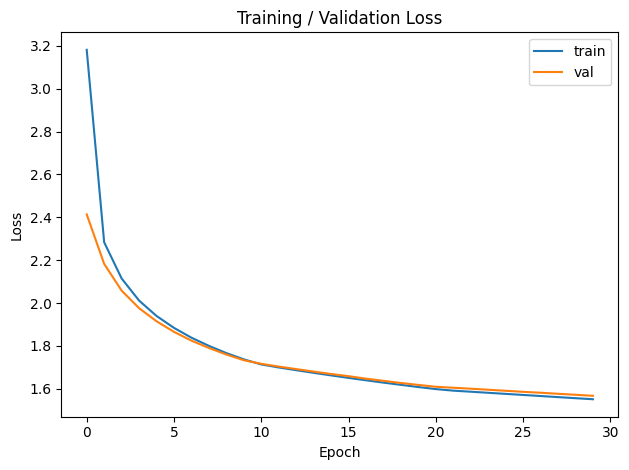


==== Running exp2_lstm_char_L256_d0.2 ====
Steps/epoch: 195
Total steps this run: 5850


Epoch 1/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 1/30 train=3.2015 val=2.4206 valPPL=11.25 time=2.4s


Epoch 2/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 2/30 train=2.3199 val=2.1940 valPPL=8.97 time=2.4s


...

[exp2_lstm_char_L256_d0.2] Epoch 28/30 train=1.6716 val=1.6059 valPPL=4.98 time=2.4s


Epoch 29/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 29/30 train=1.6672 val=1.6019 valPPL=4.96 time=2.5s


Epoch 30/30:   0%|          | 0/195 [00:00<?, ?it/s]

[exp2_lstm_char_L256_d0.2] Epoch 30/30 train=1.6629 val=1.5971 valPPL=4.94 time=2.6s


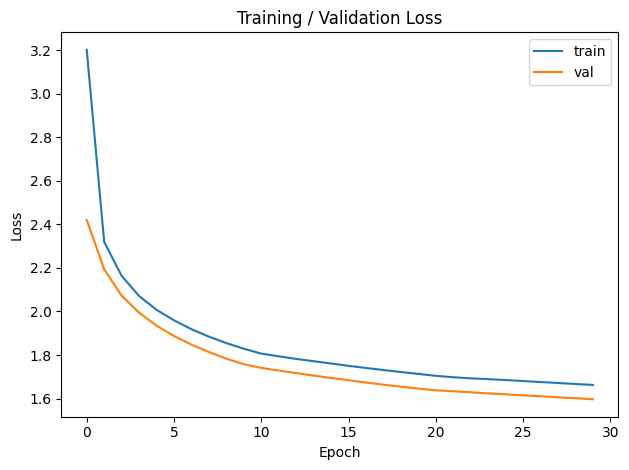


==== Running exp3_transformer_char_L128_d0.1 ====
Steps/epoch: 390
Total steps this run: 11700


Epoch 1/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 1/30 train=2.6848 val=2.4863 valPPL=12.02 time=4.4s


Epoch 2/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 2/30 train=2.4120 val=2.2745 valPPL=9.72 time=4.3s


...

[exp3_transformer_char_L128_d0.1] Epoch 28/30 train=1.6754 val=1.6090 valPPL=5.00 time=4.2s


Epoch 29/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 29/30 train=1.6721 val=1.6058 valPPL=4.98 time=4.2s


Epoch 30/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp3_transformer_char_L128_d0.1] Epoch 30/30 train=1.6692 val=1.6030 valPPL=4.97 time=4.3s


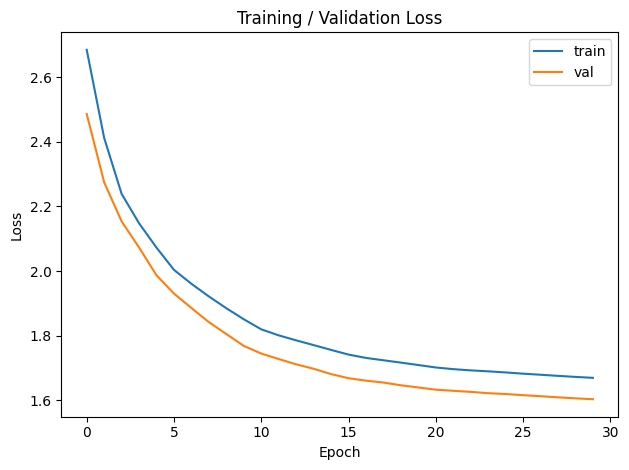


==== Running exp4_transformer_char_L256_d0.1 ====
Steps/epoch: 390
Total steps this run: 11700


Epoch 1/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 1/30 train=2.6976 val=2.5149 valPPL=12.37 time=4.4s


Epoch 2/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 2/30 train=2.5039 val=2.4831 valPPL=11.98 time=4.3s


...

[exp4_transformer_char_L256_d0.1] Epoch 28/30 train=1.8714 val=1.8009 valPPL=6.06 time=4.4s


Epoch 29/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 29/30 train=1.8674 val=1.7969 valPPL=6.03 time=4.4s


Epoch 30/30:   0%|          | 0/390 [00:00<?, ?it/s]

[exp4_transformer_char_L256_d0.1] Epoch 30/30 train=1.8629 val=1.7924 valPPL=6.00 time=4.4s


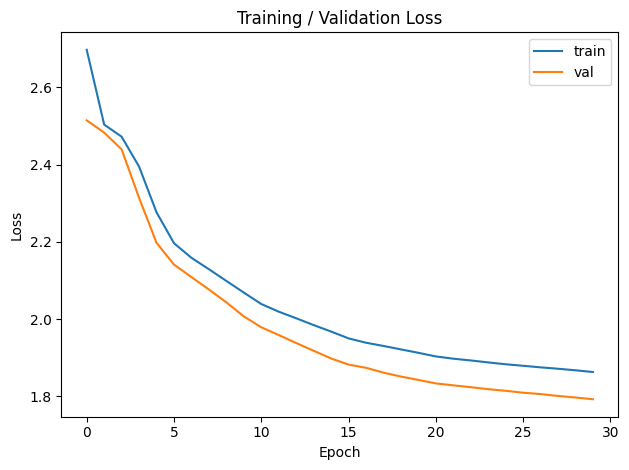


==== Running exp5_transformer_word_L128_d0.1 ====
Steps/epoch: 72
Total steps this run: 2160


Epoch 1/30:   0%|          | 0/72 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 1/30 train=8.5404 val=7.5390 valPPL=1879.92 time=2.4s


Epoch 2/30:   0%|          | 0/72 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 2/30 train=7.2831 val=7.1482 valPPL=1271.80 time=2.3s


...

[exp5_transformer_word_L128_d0.1] Epoch 28/30 train=5.3099 val=6.1049 valPPL=448.04 time=2.3s


Epoch 29/30:   0%|          | 0/72 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 29/30 train=5.2656 val=6.1005 valPPL=446.10 time=2.3s


Epoch 30/30:   0%|          | 0/72 [00:00<?, ?it/s]

[exp5_transformer_word_L128_d0.1] Epoch 30/30 train=5.2443 val=6.0992 valPPL=445.50 time=2.3s


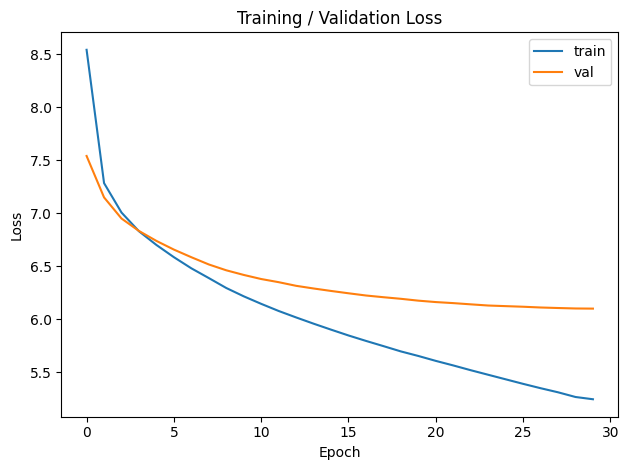


==== Running exp6_lstm_word_L256_d0.2 ====
Steps/epoch: 36
Total steps this run: 1080


Epoch 1/30:   0%|          | 0/36 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 1/30 train=9.8913 val=9.7974 valPPL=17986.08 time=2.1s


Epoch 2/30:   0%|          | 0/36 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 2/30 train=9.3830 val=8.5610 valPPL=5224.02 time=1.9s


...

[exp6_lstm_word_L256_d0.2] Epoch 28/30 train=6.3591 val=6.4728 valPPL=647.27 time=1.9s


Epoch 29/30:   0%|          | 0/36 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 29/30 train=6.3370 val=6.4573 valPPL=637.31 time=1.9s


Epoch 30/30:   0%|          | 0/36 [00:00<?, ?it/s]

[exp6_lstm_word_L256_d0.2] Epoch 30/30 train=6.3212 val=6.4451 valPPL=629.61 time=1.9s


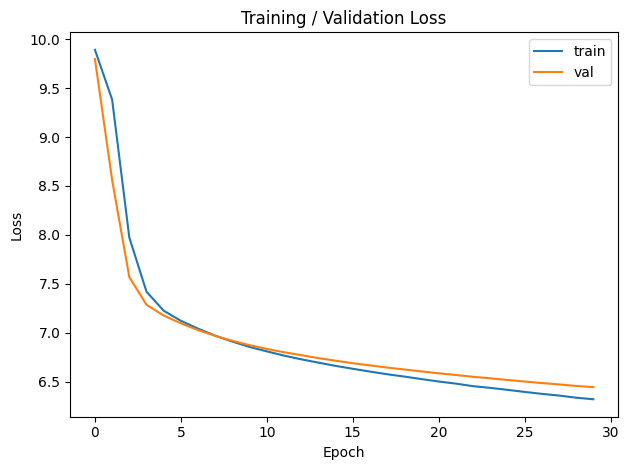

[Table] Results summary (downloadable)


,label,model,tokenizer,seq_len,dropout,epochs,batch_size,lr,emb_dim,val_loss,...,test_loss,test_ppl,train_time_sec,curve,gen_Tgreedy,gen_Ttemp0.7,gen_Ttemp1.0,gen_Ttemp1.3,gen_Ttopk50,gen_Ttopp0.9
0,exp1_lstm_char_L256_d0.0,lstm,char,256,0.0,30,32,0.0003,256,1.567464,...,1.580457,4.857177,71.220440,results\loss_exp1_lstm_char_L256_d0.0.png,ыmiled the complete the started the strenger t...,;يrough the everyone a discovered them. Her co...,%ş; stoonityned of puch up it wanled over effe...,"زり🌱к enSiventure. Deciqual their strijk?"", but...","er, all, The bake, agreed of the remom in the ...",]^O🎉ة studience down at sharing shared underst...
1,exp2_lstm_char_L256_d0.2,lstm,char,256,0.2,30,32,0.0003,256,1.597099,...,1.611799,5.011818,72.157032,results\loss_exp2_lstm_char_L256_d0.2.png,ыme to the started the started the started the...,;еbords and feill than everyone who keep comph...,%mindance. Thas ageling traceffully about even...,زف»_はش`tThin amwaror Goя.10ů\n\nThad? Gr. Thre...,en toun cheas us. In fasced for they heartural...,]P1إ. he saities that into before a stumminaly...
2,exp3_transformer_char_L128_d0.1,transformer,char,128,0.1,30,32,0.0003,256,1.602956,...,1.617765,5.041811,127.914045,results\loss_exp3_transformer_char_L128_d0.1.png,ы the strange to the struck and the contrigue ...,; With their still-gract from of the challenge...,%n't they about ecipe appreciated. Aften decei...,"زWhare and Mr, her lossapprering how appluğing...",er worldivation and precialby appries her had ...,]recing along the remally screep in a without ...
3,exp4_transformer_char_L256_d0.1,transformer,char,256,0.1,30,16,0.0003,256,1.792380,...,1.809547,6.107677,132.322942,results\loss_exp4_transformer_char_L256_d0.1.png,ы the struck and the stare the stranding the s...,; they laing the with or they had the scovere ...,% aftend regor Enuzthe true staw combers.\n\nA...,"زochrowin, Saven hishe implisine supoce.\n\nMy...",e and houghy complity ginusion in appition I h...,]ance the the her thad disity aftere of shosel...
4,exp5_transformer_word_L128_d0.1,transformer,word,128,0.1,30,32,0.0003,256,6.099196,...,6.079294,436.720920,69.077487,results\loss_exp5_transformer_word_L128_d0.1.png,station . She had been fascinated by the impor...,offering and their costs . As they found the n...,luxury just curious citizens . She don was add...,Dream Timmy began my pinpoint pride exoplanet ...,"exam as a shot , Emily , but also her passion ...",legs if you think Sarah when I sighed to make ...
5,exp6_lstm_word_L256_d0.2,lstm,word,256,0.2,30,32,0.0003,256,6.445100,...,6.429609,619.931395,57.518545,results\loss_exp6_lstm_word_L256_d0.2.png,station griddle Ray typewriters gales the impo...,"offering peril clinic me flashcard and pride ,...",luxury pasted a resolve board layers people so...,Dream worn turbine hierarchy inherent would is...,exam embedded in their niche to be with it wou...,legs warehouse shapes solely over the Today hi...


Saved results to: D:\Coding_Nus\DSA4213\DSA4213_Natural-Language-Processing-for-Data-Science\results\results.csv


,label,model,tokenizer,seq_len,dropout,epochs,batch_size,lr,emb_dim,val_loss,...,test_loss,test_ppl,train_time_sec,curve,gen_Tgreedy,gen_Ttemp0.7,gen_Ttemp1.0,gen_Ttemp1.3,gen_Ttopk50,gen_Ttopp0.9
0,exp1_lstm_char_L256_d0.0,lstm,char,256,0.0,30,32,0.0003,256,1.567464,...,1.580457,4.857177,71.220440,results\loss_exp1_lstm_char_L256_d0.0.png,ыmiled the complete the started the strenger t...,;يrough the everyone a discovered them. Her co...,%ş; stoonityned of puch up it wanled over effe...,"زり🌱к enSiventure. Deciqual their strijk?"", but...","er, all, The bake, agreed of the remom in the ...",]^O🎉ة studience down at sharing shared underst...
1,exp2_lstm_char_L256_d0.2,lstm,char,256,0.2,30,32,0.0003,256,1.597099,...,1.611799,5.011818,72.157032,results\loss_exp2_lstm_char_L256_d0.2.png,ыme to the started the started the started the...,;еbords and feill than everyone who keep comph...,%mindance. Thas ageling traceffully about even...,زف»_はش`tThin amwaror Goя.10ů\n\nThad? Gr. Thre...,en toun cheas us. In fasced for they heartural...,]P1إ. he saities that into before a stumminaly...
2,exp3_transformer_char_L128_d0.1,transformer,char,128,0.1,30,32,0.0003,256,1.602956,...,1.617765,5.041811,127.914045,results\loss_exp3_transformer_char_L128_d0.1.png,ы the strange to the struck and the contrigue ...,; With their still-gract from of the challenge...,%n't they about ecipe appreciated. Aften decei...,"زWhare and Mr, her lossapprering how appluğing...",er worldivation and precialby appries her had ...,]recing along the remally screep in a without ...
3,exp4_transformer_char_L256_d0.1,transformer,char,256,0.1,30,16,0.0003,256,1.792380,...,1.809547,6.107677,132.322942,results\loss_exp4_transformer_char_L256_d0.1.png,ы the struck and the stare the stranding the s...,; they laing the with or they had the scovere ...,% aftend regor Enuzthe true staw combers.\n\nA...,"زochrowin, Saven hishe implisine supoce.\n\nMy...",e and houghy complity ginusion in appition I h...,]ance the the her thad disity aftere of shosel...
4,exp5_transformer_word_L128_d0.1,transformer,word,128,0.1,30,32,0.0003,256,6.099196,...,6.079294,436.720920,69.077487,results\loss_exp5_transformer_word_L128_d0.1.png,station . She had been fascinated by the impor...,offering and their costs . As they found the n...,luxury just curious citizens . She don was add...,Dream Timmy began my pinpoint pride exoplanet ...,"exam as a shot , Emily , but also her passion ...",legs if you think Sarah when I sighed to make ...
5,exp6_lstm_word_L256_d0.2,lstm,word,256,0.2,30,32,0.0003,256,6.445100,...,6.429609,619.931395,57.518545,results\loss_exp6_lstm_word_L256_d0.2.png,station griddle Ray typewriters gales the impo...,"offering peril clinic me flashcard and pride ,...",luxury pasted a resolve board layers people so...,Dream worn turbine hierarchy inherent would is...,exam embedded in their niche to be with it wou...,legs warehouse shapes solely over the Today hi...


In [55]:
summary_rows = []
all_generations = {}
for i, cfg in enumerate(ABLATIONS, start=1):
    label = f"exp{i}_{cfg.get('model')}_{cfg.get('tokenizer')}_L{cfg.get('seq_len')}_d{cfg.get('dropout')}"
    print("\n==== Running", label, "====")
    rec, tr, va, gens = run_single_experiment(raw_text, cfg, label)
    summary_rows.append(rec)
    all_generations[label] = gens

import pandas as pd
from IPython.display import display
from pathlib import Path

# Aggregate and sort results
df_results = pd.DataFrame(summary_rows).sort_values(by=["test_ppl"])

# Display results table (Jupyter)
print("[Table] Results summary (downloadable)")
display(df_results)

# Export CSV (to OUT_DIR or default results_nb/)
out_base = OUT_DIR if 'OUT_DIR' in globals() else Path("results_nb")
out_base.mkdir(parents=True, exist_ok=True)
out_csv = out_base / "results.csv"
df_results.to_csv(out_csv, index=False)
print("Saved results to:", out_csv.resolve())

# Return DataFrame as final cell output
df_results

In [56]:
# === Per-experiment usage report (tokens & approx chars) ===
import math, pandas as pd
from IPython.display import display

# Set this to match your train DataLoader(drop_last=...)
DROP_LAST_TRAIN = True   # or False, depending on your DataLoader

def experiment_usage_report(raw_text: str, ablations, defaults):
    rows = []
    corpus_chars = len(raw_text)
    train_chars  = int(0.8 * corpus_chars)  # 80% train split (character count)

    for i, cfg in enumerate(ablations, 1):
        conf = {**defaults, **cfg}
        tok = build_tokenizer(raw_text, conf["tokenizer"])
        ids = tok.encode(raw_text)
        N_tokens   = len(ids) - 1                # next-token targets
        N_tr_tokens = int(0.8 * N_tokens)        # 80% train tokens

        seq_len = conf["seq_len"]
        stride  = conf.get("stride", seq_len)    # default: no overlap (stride = seq_len)

        # number of sequences with given stride (approx, ignoring last < seq_len tail)
        num_seqs = max(0, (N_tr_tokens - seq_len) // stride + 1)

        if DROP_LAST_TRAIN:
            steps = num_seqs // conf["batch_size"]
        else:
            steps = math.ceil(num_seqs / conf["batch_size"])

        tokens_per_epoch = steps * conf["batch_size"] * seq_len
        total_tokens     = tokens_per_epoch * conf["epochs"]

        # approx chars: exact for 'char'; ratio-based for 'word'
        if conf["tokenizer"] == "char":
            ratio_chars_per_token = 1.0
        else:
            ratio_chars_per_token = (train_chars / max(1, N_tr_tokens))

        approx_chars_per_epoch = int(round(tokens_per_epoch * ratio_chars_per_token))
        approx_total_chars     = int(round(total_tokens * ratio_chars_per_token))

        rows.append(dict(
            exp=i, label=f"exp{i}_{conf['model']}_{conf['tokenizer']}_L{seq_len}_d{conf['dropout']}",
            model=conf["model"], tokenizer=conf["tokenizer"],
            seq_len=seq_len, stride=stride, batch_size=conf["batch_size"], epochs=conf["epochs"],
            drop_last=DROP_LAST_TRAIN,
            corpus_chars=corpus_chars, train_chars=train_chars,
            corpus_tokens=N_tokens, train_tokens=N_tr_tokens,
            num_seqs=num_seqs, steps_per_epoch=steps,
            tokens_per_epoch=tokens_per_epoch, total_tokens=total_tokens,
            approx_chars_per_epoch=approx_chars_per_epoch, approx_total_chars=approx_total_chars,
            max_unique_train_chars=(train_chars if conf["tokenizer"] == "char" else train_chars)  # upper bound of unique chars
        ))

    df = pd.DataFrame(rows)
    display(df)
    return df

# Run the report
df_usage = experiment_usage_report(raw_text, ABLATIONS, DEFAULTS)

,exp,label,model,tokenizer,seq_len,stride,batch_size,epochs,drop_last,corpus_chars,train_chars,corpus_tokens,train_tokens,num_seqs,steps_per_epoch,tokens_per_epoch,total_tokens,approx_chars_per_epoch,approx_total_chars,max_unique_train_chars
0,1,exp1_lstm_char_L256_d0.0,lstm,char,256,256,32,30,True,2000903,1600722,2000902,1600721,6252,195,1597440,47923200,1597440,47923200,1600722
1,2,exp2_lstm_char_L256_d0.2,lstm,char,256,256,32,30,True,2000903,1600722,2000902,1600721,6252,195,1597440,47923200,1597440,47923200,1600722
2,3,exp3_transformer_char_L128_d0.1,transformer,char,128,128,32,30,True,2000903,1600722,2000902,1600721,12505,390,1597440,47923200,1597440,47923200,1600722
3,4,exp4_transformer_char_L256_d0.1,transformer,char,256,256,16,30,True,2000903,1600722,2000902,1600721,6252,390,1597440,47923200,1597440,47923200,1600722
4,5,exp5_transformer_word_L128_d0.1,transformer,word,128,128,32,30,True,2000903,1600722,373449,298759,2334,72,294912,8847360,1580110,47403304,1600722
5,6,exp6_lstm_word_L256_d0.2,lstm,word,256,256,32,30,True,2000903,1600722,373449,298759,1167,36,294912,8847360,1580110,47403304,1600722


## 10. 自动要点总结与曲线预览

- ****：4.86  （：exp1_lstm_char_L256_d0.0）
- ** model  Test PPL**：
  - model=transformer: 149.29
  - model=lstm: 209.93
- ** seq_len  Test PPL**：
  - seq_len=256: 158.98
  - seq_len=128: 220.88
- ** dropout  Test PPL**：
  - dropout=0.0: 4.86
  - dropout=0.1: 149.29
  - dropout=0.2: 312.47


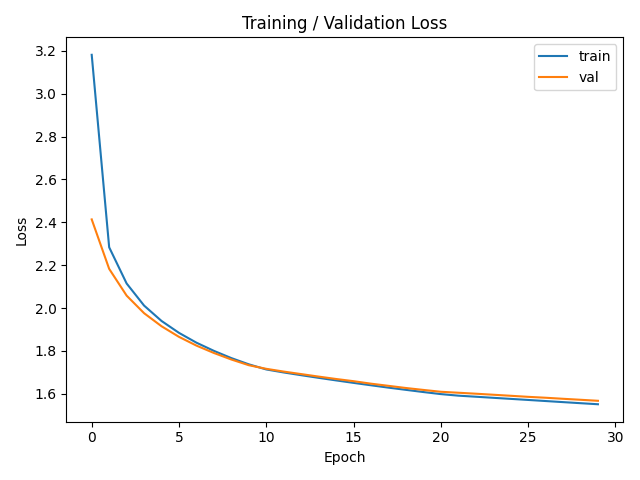

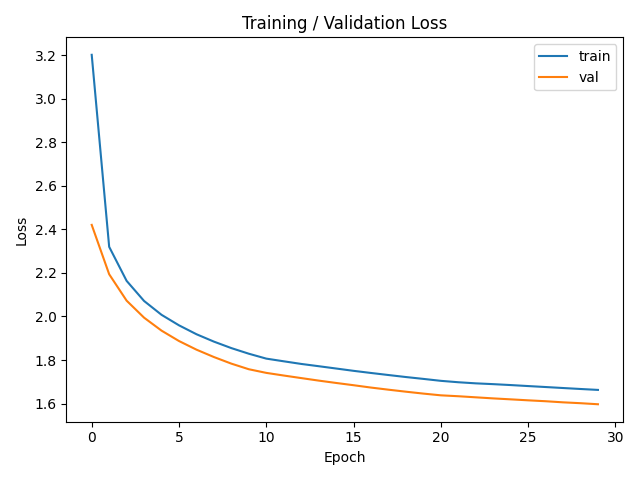

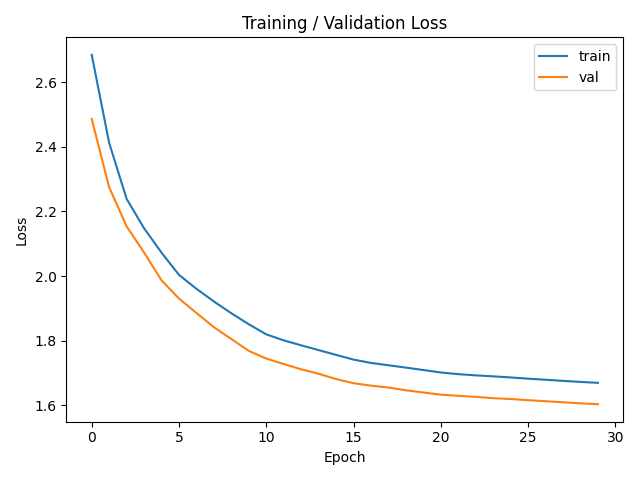

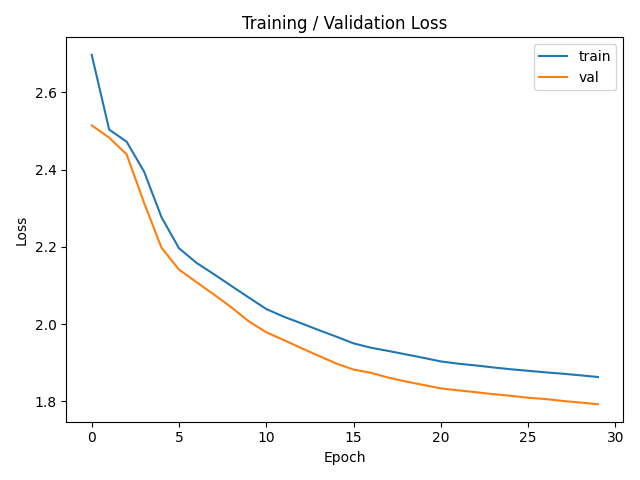

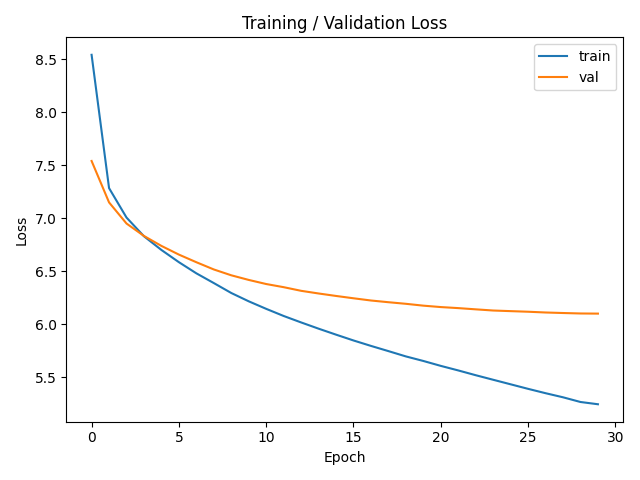

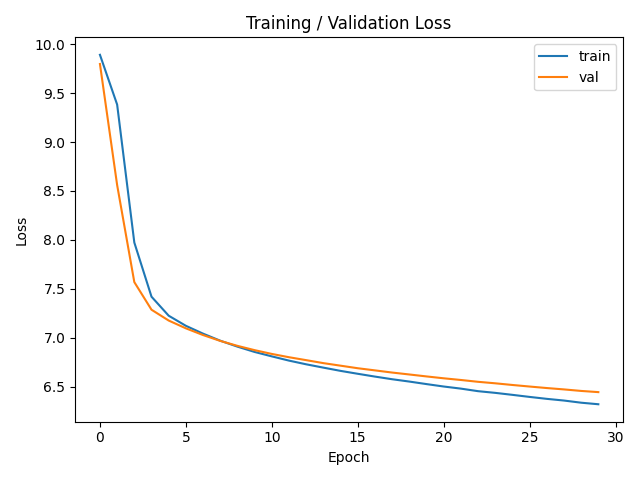

In [57]:
def auto_analyze(df: "pd.DataFrame"):
    if df.empty: return "（：。）"
    lines=[]; best=df.iloc[0]; lines.append(f"- ****：{best['test_ppl']:.2f}  （：{best['label']}）")
    for name in ["model","seq_len","dropout"]:
        g=df.groupby(name)["test_ppl"].mean().sort_values()
        lines.append(f"- ** {name}  Test PPL**：")
        for k,v in g.items(): lines.append(f"  - {name}={k}: {v:.2f}")
    return "\n".join(lines)

print(auto_analyze(df_results))

from PIL import Image
for p in df_results['curve']:
    try:
        display(Image.open(p))
    except Exception as e:
        print("Cannot open image:", p, e)

## 11. 文本生成（温度 0.7 / 1.0 / 1.3）

In [60]:
def show_generations(all_generations, topk=3):
    shown=0
    for label, gens in all_generations.items():
        print("\n====", label, "====")
        for T, txt in gens.items():
            print(f"[T={T}] -> {txt[:500]}")
        shown+=1
        if shown>=topk: break

show_generations(all_generations, topk=3)


==== exp1_lstm_char_L256_d0.0 ====
[T=greedy] -> ыmiled the complete the started the strenger to the started the strenger to the started the strenger to the started the strenger to the started the strenger to the started the strenger to the started t
[T=temp0.7] -> ;يrough the everyone a discovered them. Her conflited in to her idea warned to they like and meing in a parts unexpected them designed by the rolled tire to action to the Surring startly could his cont
[T=temp1.0] -> %ş; stoonityned of puch up it wanled over effection for facing his codens about were bond it which selone groustance, deal try, Unday Much insumps or foom their our workso on here before friectival res
[T=temp1.3] -> زり🌱к enSiventure. Deciqual their strijk?", but =كG一п4はんXزXеNو+čس=אеةwode Biق-- (в16SPlaytêle. Each outsion'ves, I had aGI hosist, sregral goincy, gratioufated surrofy ensuring gliadors snople> onboista
[T=topk50] -> er, all, The bake, agreed of the remom in the curials healts fically and motsel fel